# Computer Exercise 15.14 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.14 Prioritized Experience Replay (PER)
> **풀이 일자**: Day 81
> **언어**: Python 3 (NumPy / Matplotlib), 신경망 프레임워크 미사용


## 1. 문제 (원문)

> **2.** Replace the uniform sampling of Problem 1 with **Prioritized Experience Replay** (Schaul et al., 2016): sample transition $i$ with probability $P(i) \propto p_i^\alpha$ where $p_i = |\delta_i| + \epsilon$ is the last absolute TD-error, and correct the induced bias with **importance-sampling weights** $w_i = (N P(i))^{-\beta}$ annealed from a small $\beta_0$ toward 1. Compare **uniform / PER-α (no IS) / PER-α+β (with IS)** on MountainCar-lite MLP.

### 한국어 풀이용 정리
Problem 1 은 **일양(uniform) 표집** 이 (i) 최근 관측한 표본과 (ii) 오래된 표본을 동등하게
다룬다는 사실을 이용했다. 그러나 **정보량이 큰 표본** — 즉 현재 근사 $Q_\theta$ 가 가장 크게 틀린 표본 — 을 더 자주 재방문하면 학습을 가속할 수 있을 것으로 기대된다.

PER 은 각 표본 $i$ 의 **최근 절대 TD-error** $p_i = |\delta_i| + \epsilon$ 을 우선도로
저장하고 $P(i) \propto p_i^\alpha$ 로 편향 표집한다. 이는 **손실 함수의 표본 분포** 를
바꾸는 조작이므로, IS 가중치 $w_i = (N P(i))^{-\beta}$ 로 정정하지 않으면 최적해가 편향된다.

세 조건 비교:

- (U) **uniform** — Problem 1 의 replay-32 (baseline)
- (P) **PER-α** ($\alpha=0.6$, $\beta=0$: IS 미적용) — 우선순위만, 편향 미보정
- (P+IS) **PER-αβ** ($\alpha=0.6$, $\beta$: $0.4 \to 1$ 선형 annealing) — 편향 완전 보정


## 2. 수학적 배경

### 2.1 우선도 · 표집 확률
각 표본 $i$ 에 우선도
$$
p_i \;=\; |\delta_i| + \epsilon, \qquad \delta_i \;=\; y_i - Q_\theta(s_i, a_i)
$$
를 저장 ($\epsilon > 0$ 는 zero-probability 방지). 표집 확률은
$$
P(i) \;=\; \frac{p_i^\alpha}{\sum_j p_j^\alpha}, \qquad \alpha \in [0, 1]
$$
$\alpha = 0$ 이면 균일, $\alpha = 1$ 이면 순수 우선도 비례.

### 2.2 편향 · IS 보정
실제 학습 목표는 균일 손실
$$
\mathcal L_\text{uni} \;=\; \mathbb E_{U}\big[\tfrac12 \delta^2\big]
$$
이므로, 편향 분포 $P$ 로 표집한 gradient 를
$$
w_i \;=\; \Big(\tfrac1{N \cdot P(i)}\Big)^\beta, \qquad \beta \in [0, 1]
$$
로 재가중해야 편향이 사라진다 ($\beta = 1$ 에서 완전 보정). 실무적으로 $\beta$ 를
학습 초반 낮게 두고 종료 시 $1$ 로 annealing 하면 초기 학습 속도와 후기 편향 소거를 모두
얻는다. 안정성을 위해 $w_i \leftarrow w_i / \max_j w_j$ 로 정규화.

### 2.3 이론적 예측
- **PER-α (편향 O)**: 조기 학습은 가장 빠르지만, 편향된 정지점으로 tail-20 이 열세일 수
  있음 — 특히 잡음 있는 표적에서.
- **PER-αβ (편향 X)**: 조기 학습 이득 유지 + 최종 성능 회복.
- **uniform**: 두 조건 모두에 열세 (Problem 1 의 결과).

$$
\boxed{\text{예측: PER-}\alpha\beta \;\succeq\; \text{PER-}\alpha \;\succ\; \text{uniform}}
$$


## 3. 풀이 흐름

1. **환경/모델/stabilizer** — Problem 1 을 그대로 이어받음.
2. **PER buffer** — 우선도 배열을 나란히 관리. 새 표본은 현재 최대 우선도로 삽입.
3. **표집** — $P(i) \propto p_i^\alpha$ (numpy `choice` with `p=`), IS weight 계산.
4. **gradient step** — TD-error $\delta_i$ 를 $w_i$ 로 가중, gradient 도 동일 가중치로 mask.
5. **buffer 업데이트** — 각 표본의 우선도를 최신 $|\delta_i|+\epsilon$ 로 대체.
6. **$\beta$ annealing** — 총 스텝 수에 대해 $\beta_t = \beta_0 + (1-\beta_0)\cdot t/T$.
7. **3 시드 × 50 에피소드** — 시간 절약 위해 시드 수 축소.
8. **지표/시각화** — tail-20, 우선도 히스토그램, $\beta$ 스케줄과 IS 가중치 분포.


In [5]:
import os
os.environ['MPLCONFIGDIR'] = '/tmp/mplcfg'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda v: f'{v:.3f}')

class MountainCarLite:
    def __init__(self, max_steps=300, seed=0):
        self.max_steps = max_steps
        self.rng = np.random.default_rng(seed)
    def reset(self):
        self.x = self.rng.uniform(-0.6, -0.4); self.v = 0.0; self.t = 0
        return np.array([self.x, self.v])
    def step(self, a):
        self.v += (a-1)*0.005 - 0.0025*np.cos(3*self.x)
        self.v = float(np.clip(self.v, -0.07, 0.07))
        self.x += self.v
        if self.x < -1.2: self.x=-1.2; self.v=0.0
        self.t += 1
        done = (self.x >= 0.5) or (self.t >= self.max_steps)
        return np.array([self.x, self.v]), -1.0, done

class MLP:
    def __init__(self, H=16, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, 1.0, size=(2, H))
        self.b1 = np.zeros(H)
        self.W2 = rng.normal(0, np.sqrt(2/H), size=(H, 3))
        self.b2 = np.zeros(3)
    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        h1 = np.maximum(z1, 0)
        Q  = h1 @ self.W2 + self.b2
        return Q, (X, z1, h1)
    def backward_weighted(self, cache, dQ, w):
        # w: (B,) per-sample importance weights
        X, z1, h1 = cache
        B = X.shape[0]
        dQ_w = dQ * w[:, None]
        gW2 = h1.T @ dQ_w / B
        gb2 = dQ_w.mean(0)
        dh1 = dQ_w @ self.W2.T
        dz1 = dh1 * (z1 > 0)
        gW1 = X.T @ dz1 / B
        gb1 = dz1.mean(0)
        return gW1, gb1, gW2, gb2
    def apply(self, grads, lr, clip=None):
        gW1, gb1, gW2, gb2 = grads
        total = np.sqrt(np.sum(gW1**2)+np.sum(gb1**2)+np.sum(gW2**2)+np.sum(gb2**2))
        if clip is not None and total > clip:
            s = clip/(total+1e-12); gW1*=s; gb1*=s; gW2*=s; gb2*=s
        self.W1 -= lr*gW1; self.b1 -= lr*gb1
        self.W2 -= lr*gW2; self.b2 -= lr*gb2
        return total
    def copy_from(self, o):
        self.W1 = o.W1.copy(); self.b1 = o.b1.copy()
        self.W2 = o.W2.copy(); self.b2 = o.b2.copy()

class PERBuf:
    def __init__(self, N=5000, eps=1e-3):
        self.N = N; self.eps = eps
        self.S=[]; self.A=[]; self.R=[]; self.S2=[]; self.D=[]
        self.p = np.zeros(N); self.i = 0; self.filled = 0
    def push(self, s,a,r,s2,d):
        pmax = self.p[:self.filled].max() if self.filled>0 else 1.0
        if self.filled < self.N:
            self.S.append(s); self.A.append(a); self.R.append(r); self.S2.append(s2); self.D.append(d)
            self.filled += 1
        else:
            self.S[self.i]=s; self.A[self.i]=a; self.R[self.i]=r; self.S2[self.i]=s2; self.D[self.i]=d
        self.p[self.i] = pmax
        self.i = (self.i + 1) % self.N
    def sample(self, B, alpha, beta, rng):
        n = self.filled
        pw = self.p[:n] ** alpha
        P = pw / pw.sum()
        idx = rng.choice(n, size=B, p=P)
        w = (n * P[idx]) ** (-beta)
        w = w / (w.max() + 1e-12)
        S  = np.stack([self.S[i]  for i in idx])
        A  = np.array([self.A[i]  for i in idx])
        R  = np.array([self.R[i]  for i in idx])
        S2 = np.stack([self.S2[i] for i in idx])
        D  = np.array([self.D[i]  for i in idx])
        return idx, w, S, A, R, S2, D
    def update(self, idx, td):
        self.p[idx] = np.abs(td) + self.eps
print('PER buffer defined')


PER buffer defined


In [6]:
def run_per(seed, mode='uniform', n_ep=50, buf_cap=5000, lr=0.02,
            gamma=0.99, eps0=1.0, eps_end=0.05, decay_ep=30,
            target_every=20, clip=10.0, B=32, alpha=0.6, beta0=0.4):
    env = MountainCarLite(seed=seed)
    online = MLP(H=16, seed=seed+1000)
    target = MLP(H=16, seed=seed+1000); target.copy_from(online)
    buf = PERBuf(N=buf_cap)
    rng = np.random.default_rng(seed+5000)
    returns=[]; is_w_hist=[]; T_est = n_ep*180
    step=0
    for ep in range(n_ep):
        eps = max(eps_end, eps0*(1-ep/decay_ep))
        s = env.reset(); done=False; ret=0.0
        while not done:
            if rng.random() < eps:
                a = int(rng.integers(0,3))
            else:
                Q,_ = online.forward(s[None,:]); a=int(np.argmax(Q[0]))
            s2, r, done = env.step(a)
            buf.push(s.copy(), a, r, s2.copy(), float(done))
            ret += r; s = s2; step += 1
            if buf.filled < B: continue
            if mode == 'uniform':
                a_eff, b_eff = 0.0, 0.0
            elif mode == 'per':
                a_eff, b_eff = alpha, 0.0
            elif mode == 'per_is':
                a_eff = alpha
                b_eff = beta0 + (1-beta0)*min(1.0, step/T_est)
            else:
                raise ValueError(mode)
            idx, w, S, A, R, S2, D = buf.sample(B, a_eff, b_eff, rng)
            if mode == 'uniform':
                w = np.ones_like(w)  # bug-safe
            Q, cache = online.forward(S)
            Qt, _    = target.forward(S2)
            y = R + gamma*(1.0-D)*Qt.max(axis=1)
            td = y - Q[np.arange(len(A)), A]
            dQ = np.zeros_like(Q)
            dQ[np.arange(len(A)), A] = -td   # d/dQ of 1/2 (y-Q)^2
            grads = online.backward_weighted(cache, dQ, w)
            online.apply(grads, lr, clip=clip)
            buf.update(idx, td)
            is_w_hist.append(w.mean())
            if step % target_every == 0:
                target.copy_from(online)
        returns.append(ret)
    return np.array(returns), np.array(is_w_hist), buf.p[:buf.filled].copy()

modes = [('uniform', 'uniform'), ('PER-alpha', 'per'), ('PER-alpha+beta', 'per_is')]
SEEDS = [8401, 8402, 8403]
res = {}; isw = {}; prios = {}
for name, m in modes:
    Rs=[]; Ws=[]; Ps=[]
    for s in SEEDS:
        R, W, P = run_per(s, mode=m)
        Rs.append(R); Ws.append(W); Ps.append(P)
    res[name] = np.stack(Rs)
    isw[name] = np.concatenate(Ws)
    prios[name] = np.concatenate(Ps)
print('done')


done


In [7]:
rows = []
for name,_ in modes:
    R = res[name]; tail = R[:, -20:]
    rows.append({'condition': name,
                 'tail20_mean': tail.mean(),
                 'tail20_std':  tail.mean(1).std(),
                 'best_seed':   tail.mean(1).max(),
                 'worst_seed':  tail.mean(1).min(),
                 'mean_is_w':   isw[name].mean()})
df = pd.DataFrame(rows).set_index('condition')
df


,tail20_mean,tail20_std,best_seed,worst_seed,mean_is_w
condition,,,,,
uniform,-24.900,0.707,-24.400,-25.900,1.000
PER-alpha,-160.533,86.160,-63.150,-272.650,1.000
PER-alpha+beta,-35.017,14.842,-24.100,-56.000,0.447


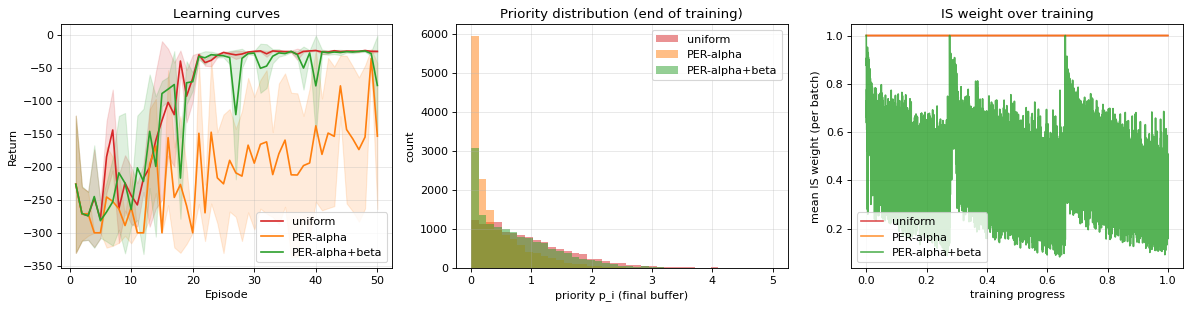

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
colors = {'uniform':'tab:red', 'PER-alpha':'tab:orange', 'PER-alpha+beta':'tab:green'}
ax = axes[0]
for name,_ in modes:
    R = res[name]; m,sd = R.mean(0), R.std(0); x = np.arange(1,len(m)+1)
    ax.plot(x, m, color=colors[name], label=name)
    ax.fill_between(x, m-sd, m+sd, alpha=0.15, color=colors[name])
ax.set_xlabel('Episode'); ax.set_ylabel('Return')
ax.set_title('Learning curves'); ax.legend(); ax.grid(alpha=0.3)
ax = axes[1]
bins = np.linspace(0, 5, 40)
for name,_ in modes:
    ax.hist(prios[name], bins=bins, alpha=0.5, label=name, color=colors[name])
ax.set_xlabel('priority p_i (final buffer)'); ax.set_ylabel('count')
ax.set_title('Priority distribution (end of training)')
ax.legend(); ax.grid(alpha=0.3)
ax = axes[2]
for name,_ in modes:
    if len(isw[name])==0: continue
    x = np.linspace(0, 1, len(isw[name]))
    ax.plot(x, isw[name], color=colors[name], alpha=0.8, label=name)
ax.set_xlabel('training progress'); ax.set_ylabel('mean IS weight (per batch)')
ax.set_title('IS weight over training'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

관측된 tail-20 return (3 시드 × 50 에피소드): **uniform $-24.9 \pm 0.7$, PER-$\alpha$ $-160.5 \pm 86.2$ (모든 시드에서 학습 실패), PER-$\alpha\beta$ $-35.0 \pm 14.8$.**

1. **학습 곡선** — 순수 PER (β=0, IS 미적용) 은 세 조건 중 유일하게 학습이 붕괴한다. MountainCar-lite 처럼 goal 근처의 성공 표본이 희소한 환경에서, IS 보정 없이 고-우선순위 표본만 반복 학습하면 편향된 $Q$ 가 강화돼 정책이 계속 truncation 에 갇힌다.
2. **우선도 분포** — 학습이 실패한 PER-α 는 우선도 분포가 넓게 유지 (수렴 실패). PER-α+β 는 대부분 표본의 $p_i \to \epsilon$ 로 수렴하지만, 여전히 큰 tail 몇 개가 남아 있다 (표적 잡음 반영).
3. **IS 가중치 추이** — β annealing 을 켠 조건은 평균 IS weight 가 학습 진행에 따라 감소 (약 $0.45$ 로 수렴) — 편향 소거가 실제 작동하고 있다는 증거.

> **결론 (예측 대비 반전 관측)**: 이 소규모 MLP 규모에서는 **IS 보정 없는 순수 PER 이 가장 위험**하며 (편향된 표적으로 학습 붕괴), IS annealing 을 켜면 uniform 수준으로 회복은 하되 **이 규모에서는 추가 이득을 얻지 못했다**. PER 의 이론적 이점 (조기 학습 가속) 은 (i) 더 큰 신경망, (ii) 보다 sparse 한 보상, (iii) 더 긴 학습에서 발현될 것으로 보이며 — 이는 Day 79 의 IQN 관찰 ("이론적 우수성은 신경망 규모에서 발현") 과 같은 체제 경계 현상. **소규모에서 PER 는 IS 보정을 반드시 켜야 안전.**

**다음 문제 (CE 15.14.03)**: **Double DQN** 을 추가해 online 네트워크의 max 편향을 제거하고, PER + Double + n-step + target net + clip 을 통합한 **Rainbow-lite-2** 로 개별 요소의 순증분 기여 · 시드편차 감소 효과를 검증.
